In [1]:
!apt-get update -qq
!apt-get install -y -qq openjdk-11-jdk-headless
!pip install -q pyspark pandas matplotlib

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package openjdk-11-jre-headless:amd64.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../openjdk-11-jre-headless_11.0.30+7-1ubuntu1~22.04_amd64.deb ...
Unpacking openjdk-11-jre-headless:amd64 (11.0.30+7-1ubuntu1~22.04) ...
Selecting previously unselected package openjdk-11-jdk-headless:amd64.
Preparing to unpack .../openjdk-11-jdk-headless_11.0.30+7-1ubuntu1~22.04_amd64.deb ...
Unpacking openjdk-11-jdk-headless:amd64 (11.0.30+7-1ubuntu1~22.04) ...
Setting up openjdk-11-jre-headless:amd64 (11.0.30+7-1ubuntu1~22.04) ...
update-alternatives: using /usr/lib/jvm/java-11-openjdk-amd64/bin/jjs to provide /usr/bin/jjs (jjs) in auto mode
update-alternatives: using /usr/lib/jvm/java-11-openjdk-amd64/bin/rmid to provide /usr/bin/rmid

In [2]:
from pathlib import Path

input_path = Path("/content/sample_data/Online_Retail.csv")

if not input_path.exists():
    raise FileNotFoundError(
        "CSV not found at /content/sample_data/Online_Retail.csv. "
        "Upload or move your Online_Retail.csv there first."
    )

print("Found:", input_path)
print("Size MB:", round(input_path.stat().st_size / 1024 / 1024, 2))

Found: /content/sample_data/Online_Retail.csv
Size MB: 43.47


In [3]:
%%writefile /content/retail_to_sft.py

import argparse
import os
from pyspark.sql import SparkSession, functions as F, Window


SYSTEM_PROMPT = (
    "You are a helpful ecommerce shopping assistant trained on historical retail transactions. "
    "Help with product questions, order-style inquiries, cancellations, returns, and product recommendations. "
    "Use only the provided historical context. Do not invent live inventory, shipping status, or real-time prices."
)


def messages_col(user_col, assistant_col):
    return F.array(
        F.struct(
            F.lit("system").alias("role"),
            F.lit(SYSTEM_PROMPT).alias("content"),
        ),
        F.struct(
            F.lit("user").alias("role"),
            user_col.alias("content"),
        ),
        F.struct(
            F.lit("assistant").alias("role"),
            assistant_col.alias("content"),
        ),
    )


def write_single_text(df, path):
    """
    Writes one JSONL-style part file by using Spark text output.
    On EMR/S3 this creates a folder with part-* files.
    """
    df.coalesce(1).write.mode("overwrite").text(path)


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--input", required=True, help="Input CSV path")
    parser.add_argument("--output", required=True, help="Output directory")
    parser.add_argument("--max_orders", type=int, default=20000)
    parser.add_argument("--max_products", type=int, default=5000)
    parser.add_argument("--max_recs", type=int, default=5000)
    parser.add_argument("--max_cancellations", type=int, default=3000)
    parser.add_argument("--max_items_per_basket", type=int, default=50)
    parser.add_argument("--train_ratio", type=float, default=0.90)
    parser.add_argument("--seed", type=int, default=42)
    args = parser.parse_args()

    spark = (
        SparkSession.builder
        .appName("retail-csv-to-chat-sft")
        .getOrCreate()
    )

    spark.sparkContext.setLogLevel("WARN")

    raw = (
        spark.read
        .option("header", True)
        .option("inferSchema", True)
        .option("multiLine", False)
        .option("escape", '"')
        .csv(args.input)
    )

    required_cols = [
        "InvoiceNo",
        "StockCode",
        "Description",
        "Quantity",
        "InvoiceDate",
        "UnitPrice",
        "CustomerID",
        "Country",
    ]

    missing_cols = [c for c in required_cols if c not in raw.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}. Found columns: {raw.columns}")

    df = (
        raw
        .select(
            F.col("InvoiceNo").cast("string").alias("InvoiceNo"),
            F.col("StockCode").cast("string").alias("StockCode"),
            F.trim(F.col("Description").cast("string")).alias("Description"),
            F.col("Quantity").cast("int").alias("Quantity"),
            F.col("InvoiceDate").cast("string").alias("InvoiceDate"),
            F.col("UnitPrice").cast("double").alias("UnitPrice"),
            F.col("CustomerID").cast("string").alias("CustomerID"),
            F.col("Country").cast("string").alias("Country"),
        )
        .filter(F.col("InvoiceNo").isNotNull())
        .filter(F.col("StockCode").isNotNull())
    )

    raw_count = df.count()

    cancelled = df.filter(
        F.col("InvoiceNo").startswith("C")
        | (F.col("Quantity") <= 0)
        | (F.col("UnitPrice") < 0)
    )

    purchases = (
        df
        .filter(~F.col("InvoiceNo").startswith("C"))
        .filter(F.col("Description").isNotNull())
        .filter(F.length(F.col("Description")) > 2)
        .filter(F.col("Quantity") > 0)
        .filter(F.col("UnitPrice") > 0)
        .dropDuplicates(
            [
                "InvoiceNo",
                "StockCode",
                "Description",
                "Quantity",
                "InvoiceDate",
                "UnitPrice",
                "CustomerID",
                "Country",
            ]
        )
    )

    purchase_count = purchases.count()
    cancellation_count = cancelled.count()

    # Pick the most frequent description as the canonical product name for each StockCode.
    desc_counts = purchases.groupBy("StockCode", "Description").count()

    w_desc = Window.partitionBy("StockCode").orderBy(
        F.desc("count"),
        F.asc("Description"),
    )

    product_names = (
        desc_counts
        .withColumn("rn", F.row_number().over(w_desc))
        .filter(F.col("rn") == 1)
        .select(
            "StockCode",
            F.col("Description").alias("ProductName"),
        )
    )

    line_items = (
        purchases
        .drop("Description")
        .join(product_names, on="StockCode", how="left")
        .withColumn("LineTotal", F.col("Quantity") * F.col("UnitPrice"))
        .filter(F.col("ProductName").isNotNull())
    )

    line_items.write.mode("overwrite").parquet(f"{args.output}/clean_purchases_parquet")

    # -----------------------------
    # Product summary examples
    # -----------------------------
    product_stats = (
        line_items
        .groupBy("StockCode", "ProductName")
        .agg(
            F.countDistinct("InvoiceNo").alias("order_count"),
            F.sum("Quantity").alias("units_sold"),
            F.avg("UnitPrice").alias("avg_price"),
            F.countDistinct("Country").alias("country_count"),
        )
        .filter(F.col("ProductName").isNotNull())
        .orderBy(F.desc("order_count"))
        .limit(args.max_products)
    )

    product_examples = (
        product_stats
        .withColumn(
            "user_text",
            F.concat(
                F.lit("Tell me about product "),
                F.col("ProductName"),
                F.lit("."),
            ),
        )
        .withColumn(
            "assistant_text",
            F.concat(
                F.lit("Product: "),
                F.col("ProductName"),
                F.lit(". Historical average unit price: £"),
                F.format_number(F.col("avg_price"), 2),
                F.lit(". It appeared in "),
                F.col("order_count").cast("string"),
                F.lit(" order(s), sold "),
                F.col("units_sold").cast("string"),
                F.lit(" unit(s), and appeared across "),
                F.col("country_count").cast("string"),
                F.lit(" country/countries in the historical dataset."),
            ),
        )
        .withColumn("example_type", F.lit("product_summary"))
        .withColumn("messages", messages_col(F.col("user_text"), F.col("assistant_text")))
        .select("example_type", "messages")
    )

    # -----------------------------
    # Order inquiry examples
    # -----------------------------
    item_text = F.concat(
        F.col("ProductName"),
        F.lit(" x"),
        F.col("Quantity").cast("string"),
        F.lit(" at £"),
        F.format_number(F.col("UnitPrice"), 2),
    )

    order_base = (
        line_items
        .withColumn("item_text", item_text)
        .groupBy("InvoiceNo", "Country")
        .agg(
            F.slice(F.collect_list("item_text"), 1, 12).alias("items"),
            F.sum("LineTotal").alias("order_total"),
            F.countDistinct("StockCode").alias("unique_items"),
        )
        .filter(F.col("unique_items") > 0)
        .orderBy(F.rand(seed=args.seed))
        .limit(args.max_orders)
    )

    order_examples = (
        order_base
        .withColumn(
            "user_text",
            F.concat(
                F.lit("What is in order invoice "),
                F.col("InvoiceNo"),
                F.lit("?"),
            ),
        )
        .withColumn(
            "assistant_text",
            F.concat(
                F.lit("Invoice "),
                F.col("InvoiceNo"),
                F.lit(" contains "),
                F.col("unique_items").cast("string"),
                F.lit(" unique product(s): "),
                F.concat_ws("; ", F.col("items")),
                F.lit(". Estimated historical total: £"),
                F.format_number(F.col("order_total"), 2),
                F.lit("."),
            ),
        )
        .withColumn("example_type", F.lit("order_inquiry"))
        .withColumn("messages", messages_col(F.col("user_text"), F.col("assistant_text")))
        .select("example_type", "messages")
    )

    # -----------------------------
    # Recommendation examples from co-purchases
    # -----------------------------
    basket_sizes = (
        line_items
        .select("InvoiceNo", "StockCode")
        .dropDuplicates(["InvoiceNo", "StockCode"])
        .groupBy("InvoiceNo")
        .agg(F.count("*").alias("basket_size"))
        .filter(F.col("basket_size") <= args.max_items_per_basket)
    )

    basket_items = (
        line_items
        .join(basket_sizes.select("InvoiceNo"), on="InvoiceNo", how="inner")
        .select("InvoiceNo", "StockCode", "ProductName")
        .filter(F.col("ProductName").isNotNull())
        .dropDuplicates(["InvoiceNo", "StockCode"])
    )

    a = basket_items.alias("a")
    b = basket_items.alias("b")

    pairs = (
        a.join(b, on="InvoiceNo")
        .filter(F.col("a.StockCode") < F.col("b.StockCode"))
        .select(
            F.col("a.StockCode").alias("a_code"),
            F.col("a.ProductName").alias("a_name"),
            F.col("b.StockCode").alias("b_code"),
            F.col("b.ProductName").alias("b_name"),
        )
    )

    directed_pairs = (
        pairs.select(
            F.col("a_code").alias("src_code"),
            F.col("a_name").alias("src_name"),
            F.col("b_name").alias("rec_name"),
        )
        .unionByName(
            pairs.select(
                F.col("b_code").alias("src_code"),
                F.col("b_name").alias("src_name"),
                F.col("a_name").alias("rec_name"),
            )
        )
    )

    pair_counts = (
        directed_pairs
        .groupBy("src_code", "src_name", "rec_name")
        .agg(F.count("*").alias("score"))
    )

    w_rec = Window.partitionBy("src_code").orderBy(
        F.desc("score"),
        F.asc("rec_name"),
    )

    top_recs = (
        pair_counts
        .withColumn("rn", F.row_number().over(w_rec))
        .filter(F.col("rn") <= 5)
        .groupBy("src_code", "src_name")
        .agg(F.collect_list("rec_name").alias("recs"))
        .filter(F.size("recs") >= 2)
        .orderBy(F.rand(seed=args.seed + 1))
        .limit(args.max_recs)
    )

    rec_examples = (
        top_recs
        .withColumn(
            "user_text",
            F.concat(
                F.lit("I like "),
                F.col("src_name"),
                F.lit(". Recommend similar or complementary products."),
            ),
        )
        .withColumn(
            "assistant_text",
            F.concat(
                F.lit("Based on historical co-purchases, customers who bought "),
                F.col("src_name"),
                F.lit(" also bought: "),
                F.concat_ws(", ", F.col("recs")),
                F.lit("."),
            ),
        )
        .withColumn("example_type", F.lit("recommendation"))
        .withColumn("messages", messages_col(F.col("user_text"), F.col("assistant_text")))
        .select("example_type", "messages")
    )

    # -----------------------------
    # Cancellation / return examples
    # -----------------------------
    cancel_base = (
        cancelled
        .filter(F.col("InvoiceNo").isNotNull())
        .groupBy("InvoiceNo")
        .agg(
            F.slice(F.collect_list(F.coalesce(F.col("Description"), F.lit("Unknown item"))), 1, 8).alias("items"),
            F.sum(F.coalesce(F.col("Quantity"), F.lit(0))).alias("net_quantity"),
        )
        .orderBy(F.rand(seed=args.seed + 2))
        .limit(args.max_cancellations)
    )

    cancel_examples = (
        cancel_base
        .withColumn(
            "user_text",
            F.concat(
                F.lit("What does invoice "),
                F.col("InvoiceNo"),
                F.lit(" mean?"),
            ),
        )
        .withColumn(
            "assistant_text",
            F.concat(
                F.lit("Invoice "),
                F.col("InvoiceNo"),
                F.lit(" appears to be a cancellation, return, or adjustment record in the historical data. "),
                F.lit("Related item descriptions include: "),
                F.concat_ws("; ", F.col("items")),
                F.lit("."),
            ),
        )
        .withColumn("example_type", F.lit("cancellation_or_return"))
        .withColumn("messages", messages_col(F.col("user_text"), F.col("assistant_text")))
        .select("example_type", "messages")
    )

    examples = (
        product_examples
        .unionByName(order_examples)
        .unionByName(rec_examples)
        .unionByName(cancel_examples)
        .withColumn("json", F.to_json(F.struct("messages")))
        .dropDuplicates(["json"])
    )

    total_examples = examples.count()

    if total_examples == 0:
        raise RuntimeError("No training examples were generated. Check input data and filters.")

    train, eval_df = examples.randomSplit(
        [args.train_ratio, 1.0 - args.train_ratio],
        seed=args.seed,
    )

    train_json = train.select(F.col("json").alias("value"))
    eval_json = eval_df.select(F.col("json").alias("value"))

    write_single_text(train_json, f"{args.output}/train_jsonl")
    write_single_text(eval_json, f"{args.output}/eval_jsonl")

    # Save typed examples too, useful for debugging and EDA.
    examples.select("example_type", "json").write.mode("overwrite").parquet(f"{args.output}/examples_with_type_parquet")

    # Summary stats.
    split_stats = (
        train.withColumn("split", F.lit("train"))
        .unionByName(eval_df.withColumn("split", F.lit("eval")))
        .groupBy("split", "example_type")
        .count()
    )

    split_stats.write.mode("overwrite").option("header", True).csv(f"{args.output}/stats/split_counts_csv")

    # Approx token estimate: whitespace token count over JSON string.
    token_stats = (
        examples
        .withColumn("approx_tokens", F.size(F.split(F.col("json"), r"\s+")))
        .select("example_type", "approx_tokens")
    )

    token_stats.write.mode("overwrite").option("header", True).csv(f"{args.output}/stats/token_lengths_csv")

    country_stats = (
        line_items
        .groupBy("Country")
        .agg(F.count("*").alias("line_count"))
        .orderBy(F.desc("line_count"))
    )

    country_stats.write.mode("overwrite").option("header", True).csv(f"{args.output}/stats/country_counts_csv")

    product_stats.select(
        "StockCode",
        "ProductName",
        "order_count",
        "units_sold",
        "avg_price",
        "country_count",
    ).write.mode("overwrite").option("header", True).csv(f"{args.output}/stats/product_stats_csv")

    summary_rows = [
        ("raw_rows", raw_count),
        ("clean_purchase_rows", purchase_count),
        ("cancel_or_return_rows", cancellation_count),
        ("total_sft_examples", total_examples),
        ("train_examples", train.count()),
        ("eval_examples", eval_df.count()),
    ]

    summary_df = spark.createDataFrame(summary_rows, ["metric", "value"])
    summary_df.write.mode("overwrite").option("header", True).csv(f"{args.output}/stats/summary_csv")

    print("ETL completed successfully.")
    print(f"Raw rows: {raw_count}")
    print(f"Clean purchase rows: {purchase_count}")
    print(f"Cancellation/return rows: {cancellation_count}")
    print(f"Total SFT examples: {total_examples}")
    print(f"Output path: {args.output}")

    spark.stop()


if __name__ == "__main__":
    main()

Writing /content/retail_to_sft.py


In [4]:
!rm -rf /content/retail_sft_output

!spark-submit /content/retail_to_sft.py \
  --input /content/sample_data/Online_Retail.csv \
  --output /content/retail_sft_output \
  --max_orders 10000 \
  --max_products 3000 \
  --max_recs 3000 \
  --max_cancellations 2000 \
  --max_items_per_basket 50

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/04/28 09:21:05 INFO SparkContext: Running Spark version 4.0.2
26/04/28 09:21:05 INFO SparkContext: OS info Linux, 6.6.113+, amd64
26/04/28 09:21:05 INFO SparkContext: Java version 17.0.18
26/04/28 09:21:06 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/04/28 09:21:06 INFO ResourceUtils: ==============================================================
26/04/28 09:21:06 INFO ResourceUtils: No custom resources configured for spark.driver.
26/04/28 09:21:06 INFO ResourceUtils: ==============================================================
26/04/28 09:21:06 INFO SparkContext: Submitted application: retail-csv-to-chat-sft
26/04/28 09:21:06 INFO ResourceProfile: Default ResourceProfile created, executor resources: Map(cores -> name: cores, amount: 1, script: , vendor: , memory -> name: memory, amount: 1024, script: , vendor: , offHe

In [5]:
!find /content/retail_sft_output -maxdepth 3 -type f | sort | head -80

/content/retail_sft_output/clean_purchases_parquet/part-00000-02f99571-a3fd-4674-b14c-5816928c0e80-c000.snappy.parquet
/content/retail_sft_output/clean_purchases_parquet/.part-00000-02f99571-a3fd-4674-b14c-5816928c0e80-c000.snappy.parquet.crc
/content/retail_sft_output/clean_purchases_parquet/part-00001-02f99571-a3fd-4674-b14c-5816928c0e80-c000.snappy.parquet
/content/retail_sft_output/clean_purchases_parquet/.part-00001-02f99571-a3fd-4674-b14c-5816928c0e80-c000.snappy.parquet.crc
/content/retail_sft_output/clean_purchases_parquet/_SUCCESS
/content/retail_sft_output/clean_purchases_parquet/._SUCCESS.crc
/content/retail_sft_output/eval_jsonl/part-00000-9aa1b11b-ea97-4ba1-b2b4-03f6fc9f4f7d-c000.txt
/content/retail_sft_output/eval_jsonl/.part-00000-9aa1b11b-ea97-4ba1-b2b4-03f6fc9f4f7d-c000.txt.crc
/content/retail_sft_output/eval_jsonl/_SUCCESS
/content/retail_sft_output/eval_jsonl/._SUCCESS.crc
/content/retail_sft_output/examples_with_type_parquet/part-00000-736c8eed-4dc9-4a54-a05b-b38f40

In [6]:
from pathlib import Path
import glob
import shutil

out = Path("/content/retail_sft_output")

def merge_text_parts(src_dir, dst_file):
    parts = sorted(glob.glob(str(Path(src_dir) / "part-*")))
    if not parts:
        raise FileNotFoundError(f"No Spark part files found in {src_dir}")
    with open(dst_file, "w", encoding="utf-8") as w:
        for p in parts:
            with open(p, "r", encoding="utf-8") as r:
                shutil.copyfileobj(r, w)

merge_text_parts(out / "train_jsonl", "/content/retail_train.jsonl")
merge_text_parts(out / "eval_jsonl", "/content/retail_eval.jsonl")

print("Created:")
print("/content/retail_train.jsonl")
print("/content/retail_eval.jsonl")

!wc -l /content/retail_train.jsonl /content/retail_eval.jsonl

Created:
/content/retail_train.jsonl
/content/retail_eval.jsonl
   16234 /content/retail_train.jsonl
    1766 /content/retail_eval.jsonl
   18000 total


In [8]:
import json
from pathlib import Path

def validate_jsonl(path, max_check=None):
    path = Path(path)
    total = 0

    with path.open("r", encoding="utf-8") as f:
        for line_no, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue

            obj = json.loads(line)

            assert "messages" in obj, f"Line {line_no}: missing messages"
            assert isinstance(obj["messages"], list), f"Line {line_no}: messages must be a list"
            assert len(obj["messages"]) == 3, f"Line {line_no}: expected 3 messages"

            roles = [m.get("role") for m in obj["messages"]]
            assert roles == ["system", "user", "assistant"], f"Line {line_no}: bad roles {roles}"

            for msg in obj["messages"]:
                assert isinstance(msg.get("content"), str), f"Line {line_no}: content must be string"
                assert len(msg["content"]) > 0, f"Line {line_no}: empty content"

            total += 1

            if max_check and total >= max_check:
                break

    print(f"Validated {total} rows from {path}")

validate_jsonl("/content/retail_train.jsonl")
validate_jsonl("/content/retail_eval.jsonl")

Validated 16234 rows from /content/retail_train.jsonl
Validated 1766 rows from /content/retail_eval.jsonl


In [9]:
import json
from itertools import islice

with open("/content/retail_train.jsonl", "r", encoding="utf-8") as f:
    for i, line in enumerate(islice(f, 5), start=1):
        obj = json.loads(line)
        print("=" * 100)
        print("EXAMPLE", i)
        for msg in obj["messages"]:
            print(f"\n[{msg['role'].upper()}]\n{msg['content'][:1200]}")

EXAMPLE 1

[SYSTEM]
You are a helpful ecommerce shopping assistant trained on historical retail transactions. Help with product questions, order-style inquiries, cancellations, returns, and product recommendations. Use only the provided historical context. Do not invent live inventory, shipping status, or real-time prices.

[USER]
What does invoice 537000 mean?

[ASSISTANT]
Invoice 537000 appears to be a cancellation, return, or adjustment record in the historical data. Related item descriptions include: Unknown item.
EXAMPLE 2

[SYSTEM]
You are a helpful ecommerce shopping assistant trained on historical retail transactions. Help with product questions, order-style inquiries, cancellations, returns, and product recommendations. Use only the provided historical context. Do not invent live inventory, shipping status, or real-time prices.

[USER]
What does invoice 537001 mean?

[ASSISTANT]
Invoice 537001 appears to be a cancellation, return, or adjustment record in the historical data. R

Summary:


,metric,value
0,raw_rows,541909
1,clean_purchase_rows,524878
2,cancel_or_return_rows,10626
3,total_sft_examples,18000
4,train_examples,16234
5,eval_examples,1766


Split counts:


,split,example_type,count
0,train,order_inquiry,8977
1,train,recommendation,2692
2,train,cancellation_or_return,1824
3,train,product_summary,2695
4,eval,recommendation,308
5,eval,product_summary,305
6,eval,cancellation_or_return,176
7,eval,order_inquiry,1023


Token lengths:


,approx_tokens
count,18000.000000
mean,100.771611
std,31.989352
min,57.000000
25%,72.000000
50%,86.000000
75%,138.000000
max,165.000000


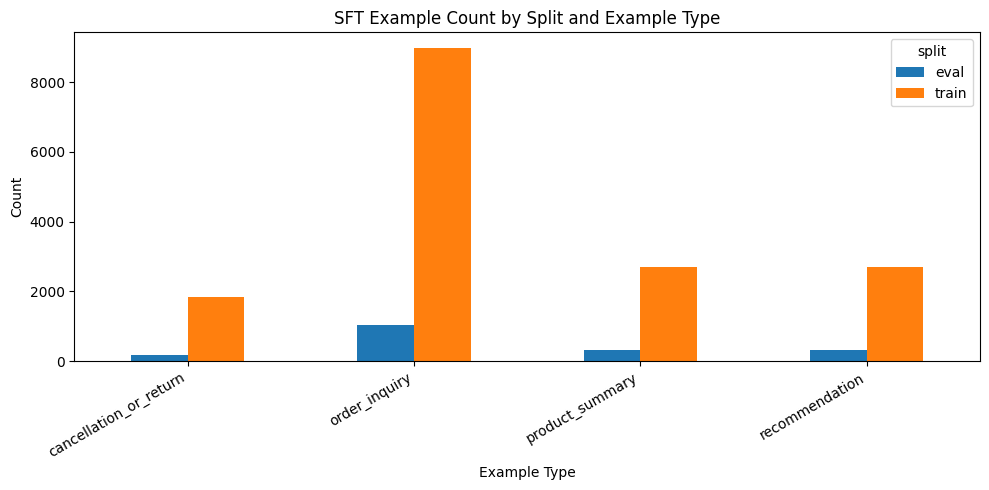

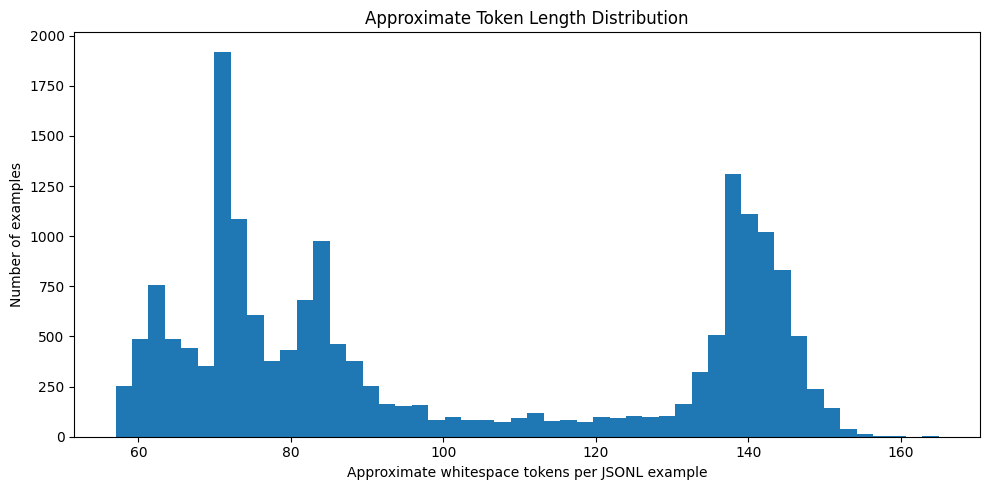

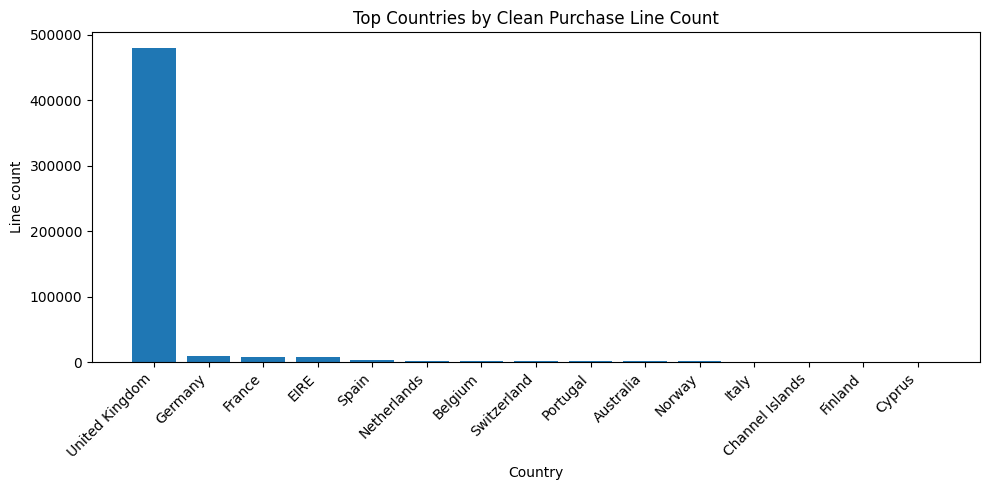

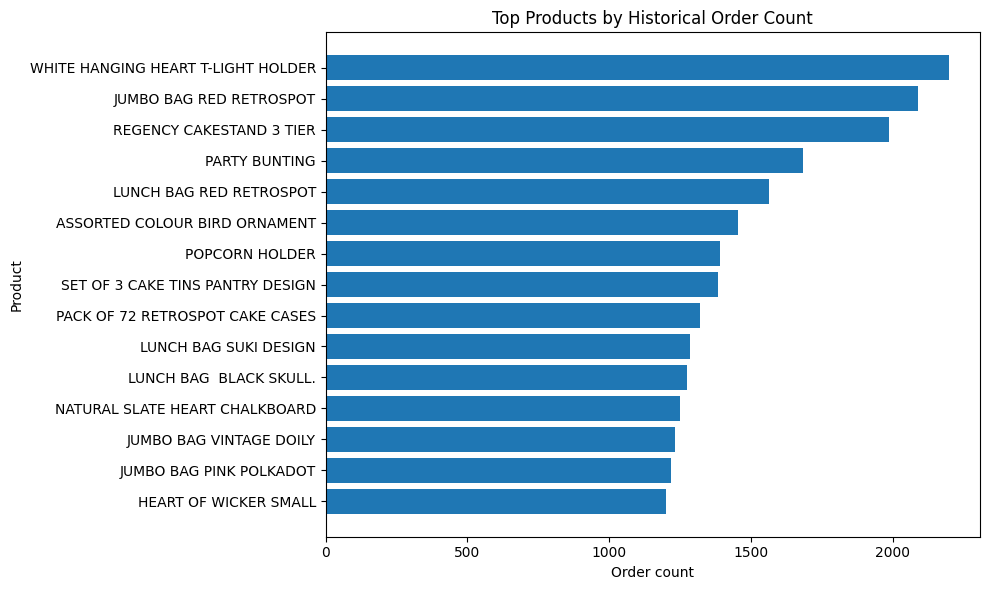

EDA figures saved to: /content/retail_sft_output/eda


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import glob

stats_dir = Path("/content/retail_sft_output/stats")
eda_dir = Path("/content/retail_sft_output/eda")
eda_dir.mkdir(parents=True, exist_ok=True)

def read_spark_csv(folder):
    parts = sorted(glob.glob(str(Path(folder) / "part-*.csv")))
    if not parts:
        raise FileNotFoundError(f"No CSV part files in {folder}")
    return pd.concat([pd.read_csv(p) for p in parts], ignore_index=True)

summary = read_spark_csv(stats_dir / "summary_csv")
split_counts = read_spark_csv(stats_dir / "split_counts_csv")
token_lengths = read_spark_csv(stats_dir / "token_lengths_csv")
country_counts = read_spark_csv(stats_dir / "country_counts_csv")
product_stats = read_spark_csv(stats_dir / "product_stats_csv")

print("Summary:")
display(summary)

print("Split counts:")
display(split_counts.head(20))

print("Token lengths:")
display(token_lengths.describe())

# Figure 1: sample count by split and example type
pivot = split_counts.pivot_table(
    index="example_type",
    columns="split",
    values="count",
    aggfunc="sum",
    fill_value=0,
)

ax = pivot.plot(kind="bar", figsize=(10, 5))
ax.set_title("SFT Example Count by Split and Example Type")
ax.set_xlabel("Example Type")
ax.set_ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(eda_dir / "figure_1_split_example_counts.png", dpi=150)
plt.show()

# Figure 2: approximate token length distribution
plt.figure(figsize=(10, 5))
plt.hist(token_lengths["approx_tokens"], bins=50)
plt.title("Approximate Token Length Distribution")
plt.xlabel("Approximate whitespace tokens per JSONL example")
plt.ylabel("Number of examples")
plt.tight_layout()
plt.savefig(eda_dir / "figure_2_token_length_distribution.png", dpi=150)
plt.show()

# Figure 3: top countries by line count
top_countries = country_counts.sort_values("line_count", ascending=False).head(15)

plt.figure(figsize=(10, 5))
plt.bar(top_countries["Country"].astype(str), top_countries["line_count"])
plt.title("Top Countries by Clean Purchase Line Count")
plt.xlabel("Country")
plt.ylabel("Line count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(eda_dir / "figure_3_top_countries.png", dpi=150)
plt.show()

# Optional Figure 4: top products by order count
top_products = product_stats.sort_values("order_count", ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_products["ProductName"].astype(str)[::-1], top_products["order_count"][::-1])
plt.title("Top Products by Historical Order Count")
plt.xlabel("Order count")
plt.ylabel("Product")
plt.tight_layout()
plt.savefig(eda_dir / "figure_4_top_products.png", dpi=150)
plt.show()

print("EDA figures saved to:", eda_dir)

In [11]:
from google.colab import files

files.download("/content/retail_train.jsonl")
files.download("/content/retail_eval.jsonl")
files.download("/content/retail_to_sft.py")
files.download("/content/retail_sft_output/eda/figure_1_split_example_counts.png")
files.download("/content/retail_sft_output/eda/figure_2_token_length_distribution.png")
files.download("/content/retail_sft_output/eda/figure_3_top_countries.png")
files.download("/content/retail_sft_output/eda/figure_4_top_products.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
from pathlib import Path

for p in ["/content/retail_train.jsonl", "/content/retail_eval.jsonl"]:
    path = Path(p)
    print(p, "exists:", path.exists(), "size MB:", round(path.stat().st_size / 1024 / 1024, 2) if path.exists() else None)

/content/retail_train.jsonl exists: True size MB: 12.49
/content/retail_eval.jsonl exists: True size MB: 1.37


In [2]:
import json

def check_jsonl(path, n=3):
    with open(path, "r", encoding="utf-8") as f:
        for i, line in enumerate(f):
            obj = json.loads(line)
            assert "messages" in obj
            assert [m["role"] for m in obj["messages"]] == ["system", "user", "assistant"]
            if i < n:
                print("=" * 80)
                print(json.dumps(obj, indent=2)[:2000])
    print("Validated:", path)

check_jsonl("/content/retail_train.jsonl")
check_jsonl("/content/retail_eval.jsonl")

{
  "messages": [
    {
      "role": "system",
      "content": "You are a helpful ecommerce shopping assistant trained on historical retail transactions. Help with product questions, order-style inquiries, cancellations, returns, and product recommendations. Use only the provided historical context. Do not invent live inventory, shipping status, or real-time prices."
    },
    {
      "role": "user",
      "content": "What does invoice 537000 mean?"
    },
    {
      "role": "assistant",
      "content": "Invoice 537000 appears to be a cancellation, return, or adjustment record in the historical data. Related item descriptions include: Unknown item."
    }
  ]
}
{
  "messages": [
    {
      "role": "system",
      "content": "You are a helpful ecommerce shopping assistant trained on historical retail transactions. Help with product questions, order-style inquiries, cancellations, returns, and product recommendations. Use only the provided historical context. Do not invent live inv

In [3]:
!nvidia-smi

Tue Apr 28 12:43:47 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
!pip install -q unsloth
!pip install -q --no-deps trl peft accelerate bitsandbytes datasets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 66.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 421.9/421.9 kB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 76.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 107.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 102.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225

In [5]:
from datasets import load_dataset

data_files = {
    "train": "/content/retail_train.jsonl",
    "validation": "/content/retail_eval.jsonl",
}

dataset = load_dataset("json", data_files=data_files)

print(dataset)
print(dataset["train"][0])

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['messages'],
        num_rows: 16234
    })
    validation: Dataset({
        features: ['messages'],
        num_rows: 1766
    })
})
{'messages': [{'role': 'system', 'content': 'You are a helpful ecommerce shopping assistant trained on historical retail transactions. Help with product questions, order-style inquiries, cancellations, returns, and product recommendations. Use only the provided historical context. Do not invent live inventory, shipping status, or real-time prices.'}, {'role': 'user', 'content': 'What does invoice 537000 mean?'}, {'role': 'assistant', 'content': 'Invoice 537000 appears to be a cancellation, return, or adjustment record in the historical data. Related item descriptions include: Unknown item.'}]}


In [6]:
from unsloth import FastLanguageModel
import torch

max_seq_length = 2048
dtype = None
load_in_4bit = True

model_name = "unsloth/Llama-3.2-3B-Instruct"

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=model_name,
    max_seq_length=max_seq_length,
    dtype=dtype,
    load_in_4bit=load_in_4bit,
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.8: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.35G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/234 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

Unsloth: Will load unsloth/llama-3.2-3b-instruct-unsloth-bnb-4bit as a legacy tokenizer.


In [7]:
def formatting_prompts_func(example):
    messages = example["messages"]
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=False,
    )
    return {"text": text}

dataset = dataset.map(formatting_prompts_func)

print(dataset["train"][0]["text"][:2000])

Map:   0%|          | 0/16234 [00:00<?, ? examples/s]

Map:   0%|          | 0/1766 [00:00<?, ? examples/s]

<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 28 Apr 2026

You are a helpful ecommerce shopping assistant trained on historical retail transactions. Help with product questions, order-style inquiries, cancellations, returns, and product recommendations. Use only the provided historical context. Do not invent live inventory, shipping status, or real-time prices.<|eot_id|><|start_header_id|>user<|end_header_id|>

What does invoice 537000 mean?<|eot_id|><|start_header_id|>assistant<|end_header_id|>

Invoice 537000 appears to be a cancellation, return, or adjustment record in the historical data. Related item descriptions include: Unknown item.<|eot_id|>


In [8]:
from unsloth import FastLanguageModel
import torch
import pandas as pd

FastLanguageModel.for_inference(model)

SYSTEM_PROMPT = (
    "You are a helpful ecommerce shopping assistant trained on historical retail transactions. "
    "Help with product questions, order-style inquiries, cancellations, returns, and product recommendations. "
    "Use only the provided historical context. Do not invent live inventory, shipping status, or real-time prices."
)

test_prompts = [
    "I like WHITE HANGING HEART T-LIGHT HOLDER. Recommend similar or complementary products.",
    "What does a cancelled invoice mean in this retail dataset?",
    "Tell me about JUMBO BAG RED RETROSPOT.",
]

def generate_answer(user_prompt, max_new_tokens=200):
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": user_prompt},
    ]

    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    inputs = tokenizer([prompt], return_tensors="pt").to("cuda")

    outputs = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        temperature=0.7,
        top_p=0.9,
        do_sample=True,
        use_cache=True,
    )

    new_tokens = outputs[:, inputs.input_ids.shape[1]:]
    return tokenizer.batch_decode(new_tokens, skip_special_tokens=True)[0].strip()

base_rows = []

for prompt in test_prompts:
    response = generate_answer(prompt)
    base_rows.append({"prompt": prompt, "base_response": response})
    print("=" * 100)
    print("PROMPT:", prompt)
    print("BASE RESPONSE:", response)

base_df = pd.DataFrame(base_rows)
base_df.to_csv("/content/base_model_responses.csv", index=False)

Both `max_new_tokens` (=200) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.1

PROMPT: I like WHITE HANGING HEART T-LIGHT HOLDER. Recommend similar or complementary products.
BASE RESPONSE: Based on historical sales data, customers who purchased the WHITE HANGING HEART T-LIGHT HOLDER also liked:

1. **STRING LIGHTS**: Fairy lights or string lights are a popular complementary product for adding ambiance to a space. They come in various colors, styles, and lengths, and are often used to match the festive atmosphere of the heart-shaped light holder.
2. **HEART SHAPE DECORATIONS**: Other heart-shaped decorations, such as heart-shaped vases, heart-themed wall art, or heart-shaped cookie jars, can be a nice addition to a room's decor.
3. **WHITE OR CLEAR FLOWERS**: A bouquet of white or clear flowers, such as roses or carnations, can add a romantic touch to a space, especially when paired with the heart-shaped light holder.
4. **ROMANTIC WALL DECOR**: Products like wall-mounted clocks, picture frames with romantic quotes, or a "Love" sign can create a cozy and intimate

Both `max_new_tokens` (=200) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


PROMPT: What does a cancelled invoice mean in this retail dataset?
BASE RESPONSE: Based on the historical retail transactions, a cancelled invoice typically refers to a sales order that was cancelled before it was processed, resulting in a loss for the seller. This could be due to various reasons, such as:

1. Customer change of mind
2. Insufficient payment
3. Product unavailability
4. Order error

When an invoice is cancelled, the transaction is reversed, and the seller may incur a loss on the amount that was already paid. This could be reflected in the sales records, inventory levels, and even the customer's account.

In the context of the dataset, a cancelled invoice would be represented as a record with a'status' field indicating 'cancelled', and possibly other relevant details such as the reason for cancellation, date of cancellation, and the amount refunded or lost.
PROMPT: Tell me about JUMBO BAG RED RETROSPOT.
BASE RESPONSE: I couldn't find any information about a product calle

In [9]:
from unsloth import FastLanguageModel

model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
    lora_alpha=16,
    lora_dropout=0,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=3407,
    use_rslora=False,
    loftq_config=None,
)

Unsloth 2026.4.8 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


In [ ]:
from trl import SFTTrainer
from transformers import TrainingArguments
from unsloth import is_bfloat16_supported

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=dataset["train"],
    eval_dataset=dataset["validation"],
    dataset_text_field="text",
    max_seq_length=max_seq_length,
    dataset_num_proc=2,
    packing=False,
    args=TrainingArguments(
        per_device_train_batch_size=2,
        gradient_accumulation_steps=4,
        warmup_steps=20,
        num_train_epochs=1,
        learning_rate=2e-4,
        fp16=not is_bfloat16_supported(),
        bf16=is_bfloat16_supported(),
        logging_steps=10,
        eval_strategy="steps",
        eval_steps=50,
        save_steps=100,
        optim="adamw_8bit",
        weight_decay=0.01,
        lr_scheduler_type="linear",
        seed=3407,
        output_dir="/content/retail_unsloth_outputs",
        report_to="none",
    ),
)

trainer_stats = trainer.train()

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/16234 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/1766 [00:00<?, ? examples/s]

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 16,234 | Num Epochs = 1 | Total steps = 2,030
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 24,313,856 of 3,237,063,680 (0.75% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Step,Training Loss,Validation Loss
50,0.952339,0.861375
100,0.726324,0.642945
150,0.610590,0.552966
200,0.554708,0.498791
250,0.510970,0.467581
300,0.487255,0.444187
350,0.425661,0.423371
400,0.471349,0.408894
450,0.443614,0.394702
500,0.437560,0.385442


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API i

In [ ]:
model.save_pretrained("/content/retail_assistant_lora")
tokenizer.save_pretrained("/content/retail_assistant_lora")

In [ ]:
FastLanguageModel.for_inference(model)

ft_rows = []

for row in base_rows:
    prompt = row["prompt"]
    response = generate_answer(prompt)
    ft_rows.append({
        "prompt": prompt,
        "base_response": row["base_response"],
        "fine_tuned_response": response,
    })

    print("=" * 100)
    print("PROMPT:", prompt)
    print("\nBASE RESPONSE:\n", row["base_response"])
    print("\nFINE-TUNED RESPONSE:\n", response)

comparison_df = pd.DataFrame(ft_rows)
comparison_df.to_csv("/content/base_vs_finetuned_responses.csv", index=False)
comparison_df

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

logs = trainer.state.log_history
log_df = pd.DataFrame(logs)
log_df.to_csv("/content/training_log.csv", index=False)

loss_df = log_df.dropna(subset=["loss"]) if "loss" in log_df.columns else pd.DataFrame()

if not loss_df.empty:
    plt.figure(figsize=(8, 5))
    plt.plot(loss_df["step"], loss_df["loss"])
    plt.title("Training Loss Curve")
    plt.xlabel("Step")
    plt.ylabel("Training Loss")
    plt.tight_layout()
    plt.savefig("/content/training_loss_curve.png", dpi=150)
    plt.show()
else:
    print("No loss values found in trainer log.")

In [ ]:
model.save_pretrained_gguf(
    "/content/retail_assistant_gguf",
    tokenizer,
    quantization_method="q4_k_m",
)

In [ ]:
!find /content/retail_assistant_gguf -type f -name "*.gguf" -ls

In [ ]:
import glob
import shutil
from pathlib import Path

ggufs = glob.glob("/content/retail_assistant_gguf/**/*.gguf", recursive=True)

if not ggufs:
    raise FileNotFoundError("No GGUF file found.")

src = ggufs[0]
dst = "/content/retail-assistant.Q4_K_M.gguf"

shutil.copy(src, dst)

print("Copied:")
print(src)
print("to")
print(dst)

In [ ]:
from google.colab import files

files.download("/content/retail-assistant.Q4_K_M.gguf")
files.download("/content/base_vs_finetuned_responses.csv")
files.download("/content/training_log.csv")
files.download("/content/training_loss_curve.png")
files.download("/content/retail_train.jsonl")
files.download("/content/retail_eval.jsonl")